In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor, Pool

In [3]:
INPUT_CSV = "data/processed/CATBOOST_READY_CLEAN_FLOORS.csv"
TARGET = "target_height"
RANDOM_STATE = 42
N_SPLITS = 5

BAD_IDS = [22196.0, 77650.0, 31536.0, 113305.0, 80618.0, 152373.0, 104813.0, 95834.0]

FEATURES_CB = [
    "floor_count", "ml_category", "knn_mean_floors_5", 
    "complex_total_area", "perimeter_m", "actual_area_sqm", "log_area",
]

FEATURES_LGB = [
    "ml_category", "coord_x", "coord_y", "floor_count", 
    "actual_area_sqm", "spatial_cluster", "perimeter_m", "compactness", 
    "complex_total_area"
]

FEATURES_XGB = [
    "floor_count", "ml_category", "vertex_count", 
    "coord_x", "spatial_cluster", "complex_total_area"
]

ALL_CATEGORICAL = ["ml_category", "spatial_cluster"]

# =========================================================
# 2. ПАРАМЕТРЫ
# =========================================================
CB_PARAMS = {
    'loss_function': 'MAE', 'eval_metric': 'MAE', 'random_seed': RANDOM_STATE, 'verbose': 0,
    'iterations': 2059, 'learning_rate': 0.04429758340427974, 'depth': 10,
    'l2_leaf_reg': 2.6650159568189795, 'random_strength': 0.22094525478009874,
    'bagging_temperature': 0.9999961975165181, 'border_count': 254,
}

LGB_PARAMS = {
    'objective': 'regression_l1', 'metric': 'mae', 'random_state': RANDOM_STATE, 'verbose': -1, 'n_jobs': -1,
    'n_estimators': 2359, 'learning_rate': 0.05552468672481143, 'num_leaves': 78,
    'max_depth': 12, 'min_child_samples': 27, 'subsample': 0.9593884201060788,
    'colsample_bytree': 0.995856699728964, 'reg_alpha': 7.880838703764818,
    'reg_lambda': 6.087470968947802,
}

XGB_PARAMS = {
    'objective': 'reg:absoluteerror', 'eval_metric': 'mae', 'random_state': RANDOM_STATE, 
    'enable_categorical': True, 'n_jobs': -1,
    'n_estimators': 1889, 'learning_rate': 0.0573029794489679, 'max_depth': 10,
    'subsample': 0.9300359919024406, 'colsample_bytree': 0.8686935414906535,
    'reg_alpha': 9.842615511519728, 'reg_lambda': 4.8693403567894755,
}


def get_dynamic_knn_height(train_coords, train_target, target_coords, is_train_set=False):
    k = 6 if is_train_set else 5
    nn = NearestNeighbors(n_neighbors=k, n_jobs=-1)
    nn.fit(train_coords)
    distances, indices = nn.kneighbors(target_coords)
    if is_train_set:
        indices = indices[:, 1:] 
    heights = train_target.iloc[indices.flatten()].values.reshape(indices.shape)
    return np.nanmean(heights, axis=1)


df_raw = pd.read_csv(INPUT_CSV)
train_df = df_raw[df_raw[TARGET].notna()].copy()
train_df = train_df[~train_df['id'].isin(BAD_IDS)].reset_index(drop=True)


all_features_set = list(set(FEATURES_CB + FEATURES_LGB + FEATURES_XGB))

X_base = train_df[all_features_set].copy()
y = train_df[TARGET].copy()
coords = train_df[['coord_x', 'coord_y']]

for col in ALL_CATEGORICAL:
    if col in X_base.columns:
        X_base[col] = X_base[col].fillna("Unknown").astype("category")


kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

oof_df = pd.DataFrame({"target": y, "id": train_df["id"]})
oof_df["pred_cb"] = np.nan
oof_df["pred_lgb"] = np.nan
oof_df["pred_xgb"] = np.nan


for fold, (train_idx, valid_idx) in enumerate(kf.split(X_base, y), start=1):
    
    # Разделяем базу
    X_train = X_base.iloc[train_idx].copy()
    X_valid = X_base.iloc[valid_idx].copy()
    
    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]
    
    # Честный расчет соседей
    coords_train = coords.iloc[train_idx]
    coords_valid = coords.iloc[valid_idx]
    
    X_train['knn_mean_height_5'] = get_dynamic_knn_height(coords_train, y_train, coords_train, is_train_set=True)
    X_valid['knn_mean_height_5'] = get_dynamic_knn_height(coords_train, y_train, coords_valid, is_train_set=False)
    
    # cb
    X_train_cb = X_train[FEATURES_CB].copy()
    X_valid_cb = X_valid[FEATURES_CB].copy()
    cat_cb = [c for c in ALL_CATEGORICAL if c in FEATURES_CB]
    
    for col in cat_cb:
        X_train_cb[col] = X_train_cb[col].astype(str)
        X_valid_cb[col] = X_valid_cb[col].astype(str)
        
    train_pool = Pool(X_train_cb, y_train, cat_features=cat_cb)
    valid_pool = Pool(X_valid_cb, y_valid, cat_features=cat_cb)
    
    model_cb = CatBoostRegressor(**CB_PARAMS)
    model_cb.fit(train_pool, eval_set=valid_pool)
    oof_df.loc[valid_idx, "pred_cb"] = model_cb.predict(valid_pool)

    # light
    X_train_lgb = X_train[FEATURES_LGB]
    X_valid_lgb = X_valid[FEATURES_LGB]
    cat_lgb = [c for c in ALL_CATEGORICAL if c in FEATURES_LGB]
    
    model_lgb = LGBMRegressor(**LGB_PARAMS)
    model_lgb.fit(X_train_lgb, y_train, eval_set=[(X_valid_lgb, y_valid)], 
                  categorical_feature=cat_lgb, callbacks=[])
    oof_df.loc[valid_idx, "pred_lgb"] = model_lgb.predict(X_valid_lgb)

    # xg
    X_train_xgb = X_train[FEATURES_XGB]
    X_valid_xgb = X_valid[FEATURES_XGB]
    
    model_xgb = XGBRegressor(**XGB_PARAMS)
    model_xgb.fit(X_train_xgb, y_train, eval_set=[(X_valid_xgb, y_valid)], verbose=0)
    oof_df.loc[valid_idx, "pred_xgb"] = model_xgb.predict(X_valid_xgb)


print("\nМетрики OOF")
mae_cb = mean_absolute_error(oof_df['target'], oof_df['pred_cb'])
mae_lgb = mean_absolute_error(oof_df['target'], oof_df['pred_lgb'])
mae_xgb = mean_absolute_error(oof_df['target'], oof_df['pred_xgb'])

print(f"CatBoost MAE: {mae_cb:.4f}")
print(f"XGBoost MAE:  {mae_xgb:.4f}")
print(f"LightGBM MAE: {mae_lgb:.4f}")


Метрики OOF
CatBoost MAE: 0.6097
XGBoost MAE:  0.5839
LightGBM MAE: 0.5217


МАТРИЦА КОРРЕЛЯЦИИ ПРЕДСКАЗАНИЙ:
          pred_cb  pred_lgb  pred_xgb
pred_cb    1.0000    0.9982    0.9979
pred_lgb   0.9982    1.0000    0.9988
pred_xgb   0.9979    0.9988    1.0000


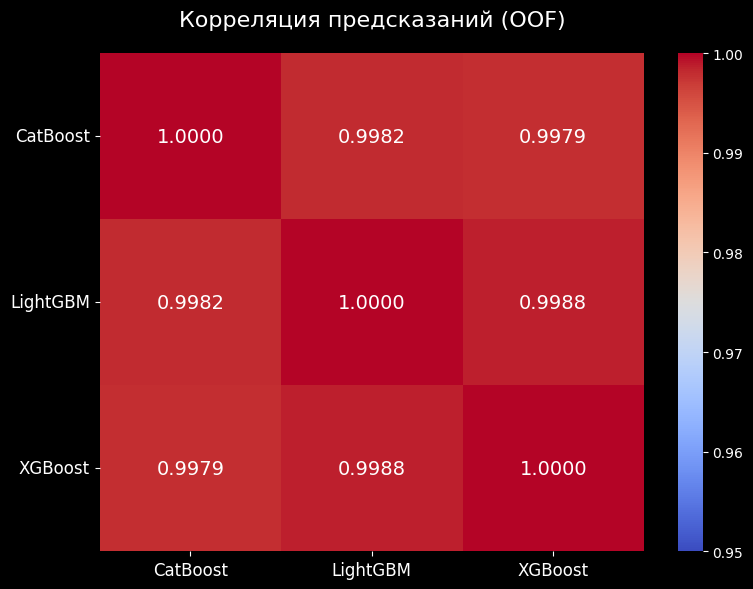

In [7]:
corr_matrix = oof_df[["pred_cb", "pred_lgb", "pred_xgb"]].corr()

print("МАТРИЦА КОРРЕЛЯЦИИ ПРЕДСКАЗАНИЙ:")
print(corr_matrix.round(4))

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".4f", 
    vmin=0.95, # нижняя граница, чтобы подсветить разницу
    vmax=1.0, 
    annot_kws={"size": 14}
)
plt.title('Корреляция предсказаний (OOF)', fontsize=16, pad=20)
plt.xticks(ticks=[0.5, 1.5, 2.5], labels=['CatBoost', 'LightGBM', 'XGBoost'], fontsize=12)
plt.yticks(ticks=[0.5, 1.5, 2.5], labels=['CatBoost', 'LightGBM', 'XGBoost'], fontsize=12, rotation=0)

plt.tight_layout()
plt.savefig('correlation_matrix_real.png', dpi=300)
plt.show()

### после просмотра модели можно заметить ошибки в разметке церквей и тц, которые изначально были заложены в датасете, обратимся к OpenStreetMap для более точной отрисовки архитектурных зданий - гипотеза отклонена, не удалось спарсить данные 